# Food & Restaurant AI Demand Forecasting and Inventory Optimization 

# Week 2: Advanced Feature Engineering for Time-Series Forecasting

- In this notebook, we transform the cleaned time-series dataset into a model-ready format using advanced feature engineering techniques.

# Objectives:
- Extract meaningful time-based features
- Create lag features to capture past dependencies
- Generate rolling statistics (trend & volatility)
- Apply cyclical encoding for seasonality
- Prevent data leakage
- Perform time-series aware train-test split
- Prepare dataset for machine learning models

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler

##  Data Loading

Load the processed dataset generated from Week 1.

In [2]:
# Loading processed dataset from Week 1
df = pd.read_csv('../data/processed/daily_demand.csv')

# Converting to datetime
df['date'] = pd.to_datetime(df['date'])

# Sorting chronologically
df = df.sort_values('date').reset_index(drop=True)

df.head()

,date,quantity
0,2024-04-01,475
1,2024-04-02,456
2,2024-04-03,466
3,2024-04-04,415
4,2024-04-05,446


# Date-Based Feature Engineering
- Extract useful time-based features from the date column.
- These features help the model understand temporal patterns.

In [3]:
df['day'] = df['date'].dt.day
df['month'] = df['date'].dt.month
df['year'] = df['date'].dt.year

df['day_of_week'] = df['date'].dt.dayofweek
df['week_of_year'] = df['date'].dt.isocalendar().week.astype(int)

df['is_weekend'] = df['day_of_week'].isin([5, 6]).astype(int)

df.head()

,date,quantity,day,month,year,day_of_week,week_of_year,is_weekend
0,2024-04-01,475,1,4,2024,0,14,0
1,2024-04-02,456,2,4,2024,1,14,0
2,2024-04-03,466,3,4,2024,2,14,0
3,2024-04-04,415,4,4,2024,3,14,0
4,2024-04-05,446,5,4,2024,4,14,0


## Cyclical Encoding

Time-based features such as days and months are cyclical in nature.

We transform them using sine and cosine functions to preserve their cyclical relationships:
- Day of week (weekly pattern)
- Month (yearly seasonality)

This helps models better understand periodic behavior.

In [4]:
df['day_of_week_sin'] = np.sin(2 * np.pi * df['day_of_week'] / 7)
df['day_of_week_cos'] = np.cos(2 * np.pi * df['day_of_week'] / 7)

df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)

df.head()

,date,quantity,day,month,year,day_of_week,week_of_year,is_weekend,day_of_week_sin,day_of_week_cos,month_sin,month_cos
0,2024-04-01,475,1,4,2024,0,14,0,0.000000,1.000000,0.866025,-0.5
1,2024-04-02,456,2,4,2024,1,14,0,0.781831,0.623490,0.866025,-0.5
2,2024-04-03,466,3,4,2024,2,14,0,0.974928,-0.222521,0.866025,-0.5
3,2024-04-04,415,4,4,2024,3,14,0,0.433884,-0.900969,0.866025,-0.5
4,2024-04-05,446,5,4,2024,4,14,0,-0.433884,-0.900969,0.866025,-0.5


## Trend Feature

A trend feature is added to represent the progression of time.

This allows models to capture long-term upward or downward patterns in demand.

In [5]:
df['trend'] = np.arange(len(df))

## Lag Features

Lag features allow the model to learn from past observations.

We create multiple lag features to capture:
- Short-term patterns (lag_1, lag_3)
- Weekly seasonality (lag_7)
- Medium-term trends (lag_14, lag_21)

These features are essential for time-series forecasting models.

In [6]:
lags = [1, 3, 7, 14, 21]

for lag in lags:
    df[f'lag_{lag}'] = df['quantity'].shift(lag)

df.head()

,date,quantity,day,month,year,day_of_week,week_of_year,is_weekend,day_of_week_sin,day_of_week_cos,month_sin,month_cos,trend,lag_1,lag_3,lag_7,lag_14,lag_21
0,2024-04-01,475,1,4,2024,0,14,0,0.000000,1.000000,0.866025,-0.5,0,NaN,NaN,NaN,NaN,NaN
1,2024-04-02,456,2,4,2024,1,14,0,0.781831,0.623490,0.866025,-0.5,1,475.0,NaN,NaN,NaN,NaN
2,2024-04-03,466,3,4,2024,2,14,0,0.974928,-0.222521,0.866025,-0.5,2,456.0,NaN,NaN,NaN,NaN
3,2024-04-04,415,4,4,2024,3,14,0,0.433884,-0.900969,0.866025,-0.5,3,466.0,475.0,NaN,NaN,NaN
4,2024-04-05,446,5,4,2024,4,14,0,-0.433884,-0.900969,0.866025,-0.5,4,415.0,456.0,NaN,NaN,NaN


# Rolling Features (Leakage-Free)

- Rolling statistics capture trends and variability.

IMPORTANT:
- We shift before rolling to avoid using future data (data leakage).

In [7]:
windows = [3, 7, 14]

for window in windows:
    df[f'rolling_mean_{window}'] = df['quantity'].shift(1).rolling(window).mean()
    df[f'rolling_std_{window}'] = df['quantity'].shift(1).rolling(window).std()

df.head()

,date,quantity,day,month,year,day_of_week,week_of_year,is_weekend,day_of_week_sin,day_of_week_cos,...,lag_3,lag_7,lag_14,lag_21,rolling_mean_3,rolling_std_3,rolling_mean_7,rolling_std_7,rolling_mean_14,rolling_std_14
0,2024-04-01,475,1,4,2024,0,14,0,0.000000,1.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2024-04-02,456,2,4,2024,1,14,0,0.781831,0.623490,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2024-04-03,466,3,4,2024,2,14,0,0.974928,-0.222521,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2024-04-04,415,4,4,2024,3,14,0,0.433884,-0.900969,...,475.0,NaN,NaN,NaN,465.666667,9.504385,NaN,NaN,NaN,NaN
4,2024-04-05,446,5,4,2024,4,14,0,-0.433884,-0.900969,...,456.0,NaN,NaN,NaN,445.666667,27.024680,NaN,NaN,NaN,NaN


## Handling Missing Values

Lag and rolling features introduce missing values at the beginning of the dataset.

These rows are safely removed since they do not contain sufficient historical context.

In [8]:
df = df.dropna().reset_index(drop=True)
df.head()

,date,quantity,day,month,year,day_of_week,week_of_year,is_weekend,day_of_week_sin,day_of_week_cos,...,lag_3,lag_7,lag_14,lag_21,rolling_mean_3,rolling_std_3,rolling_mean_7,rolling_std_7,rolling_mean_14,rolling_std_14
0,2024-04-22,410,22,4,2024,0,17,0,0.000000,1.000000,...,476.0,429.0,444.0,475.0,494.666667,18.502252,473.142857,29.288385,463.357143,27.886051
1,2024-04-23,405,23,4,2024,1,17,0,0.781831,0.623490,...,495.0,460.0,426.0,456.0,472.666667,55.012120,470.428571,34.481189,460.928571,31.007355
2,2024-04-24,455,24,4,2024,2,17,0,0.974928,-0.222521,...,513.0,491.0,474.0,466.0,442.666667,60.961737,462.571429,42.570949,459.428571,33.253604
3,2024-04-25,486,25,4,2024,3,17,0,0.433884,-0.900969,...,410.0,448.0,449.0,415.0,423.333333,27.537853,457.428571,40.697490,458.071429,32.999917
4,2024-04-26,512,26,4,2024,4,17,0,-0.433884,-0.900969,...,405.0,476.0,493.0,446.0,448.666667,40.869712,462.857143,41.750962,460.714286,33.691881


## Prepare dataset for modeling

In [9]:
target = 'quantity'

features = [col for col in df.columns if col not in ['date', target, 'year']]

print("Total Features:", len(features))

Total Features: 21


# Time-Series Train-Test Split
# We split data chronologically to prevent leakage.
- 80% → Training (Past)
- 20% → Testing (Future)

In [10]:
df_model = df.copy() 

In [11]:
# Time-Series Train-Test Split

train_size = int(len(df_model) * 0.8)

train = df_model.iloc[:train_size]
test = df_model.iloc[train_size:]

print("Train shape:", train.shape)
print("Test shape:", test.shape)

Train shape: (275, 24)
Test shape: (69, 24)


## Define X (Features) and y (Target) for Train/Test Sets

In [12]:
# Separate features and target

X_train = train[features]
y_train = train[target]

X_test = test[features]
y_test = test[target]

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

X_train: (275, 21)
X_test: (69, 21)


# Feature Scaling

- Scaling improves performance for models like Linear Regression.
- Tree-based models are not affected but scaling ensures consistency.

In [13]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Feature Importance (Correlation with Target)

- Helps identify which features influence demand the most.

In [14]:
corr = df.corr(numeric_only=True)['quantity'].sort_values(ascending=False)
print(corr.head(10))

quantity          1.000000
day_of_week       0.096113
month             0.092810
lag_7             0.076202
week_of_year      0.074248
is_weekend        0.054172
month_cos         0.050612
lag_3             0.047898
rolling_mean_3    0.036901
lag_1             0.008175
Name: quantity, dtype: float64


## Feature Correlation Check

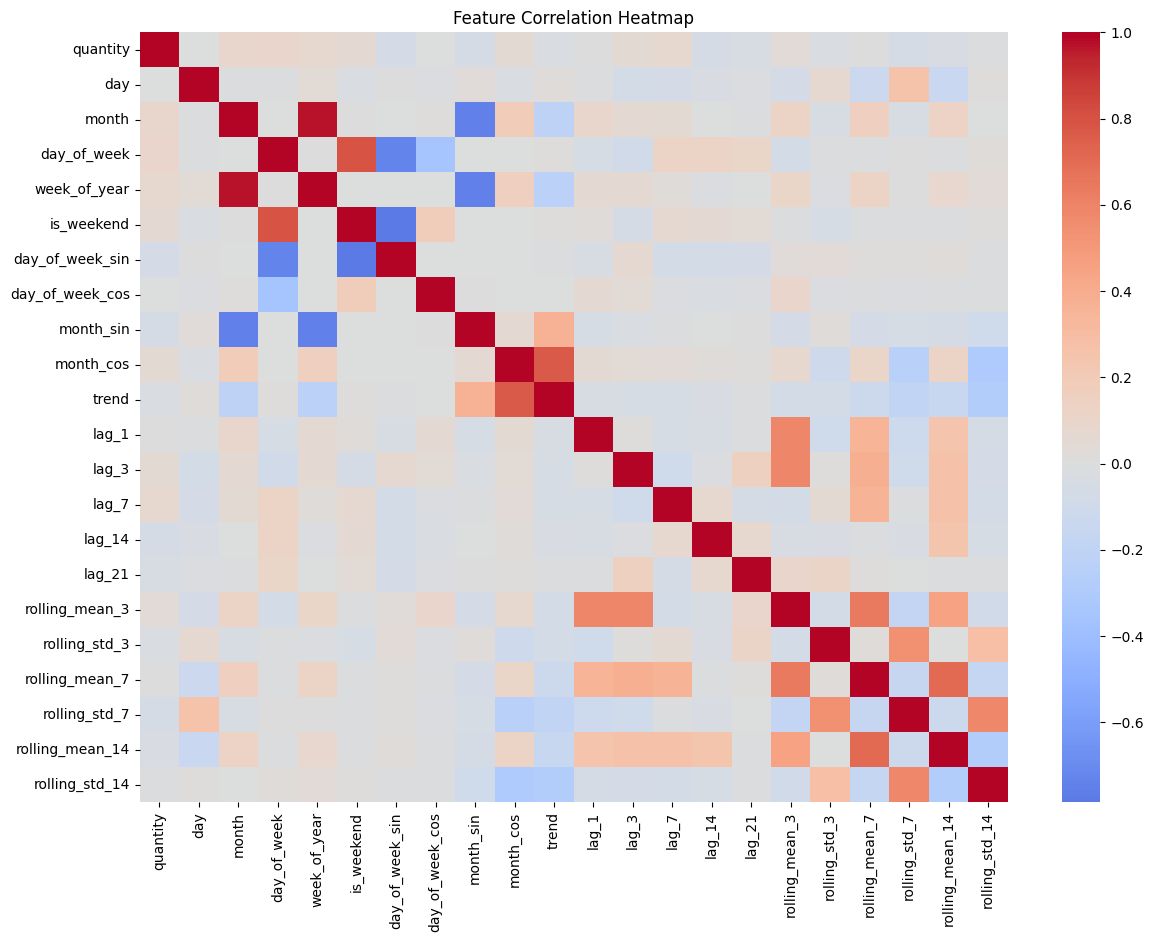

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14, 10))

corr = df.drop(columns=['date', 'year']).corr()

sns.heatmap(corr, cmap='coolwarm', center=0)
plt.title("Feature Correlation Heatmap")
plt.show()

## Save processed datasets

In [16]:
# Saving processed datasets

df_model.to_csv('../data/processed/model_ready_data.csv', index=False)

train.to_csv('../data/processed/train.csv', index=False)
test.to_csv('../data/processed/test.csv', index=False)

print("Files saved successfully!")

Files saved successfully!


## FEATURE IMPORTANCE PREVIEW

In [17]:
# feature importance using correlation with target

corr_with_target = df_model.corr()['quantity'].sort_values(ascending=False)

print(corr_with_target)

quantity           1.000000
day_of_week        0.096113
month              0.092810
lag_7              0.076202
week_of_year       0.074248
is_weekend         0.054172
month_cos          0.050612
lag_3              0.047898
rolling_mean_3     0.036901
lag_1              0.008175
rolling_mean_7     0.003735
day               -0.002065
day_of_week_cos   -0.003269
rolling_std_14    -0.015993
rolling_std_3     -0.026435
trend             -0.029621
date              -0.029621
rolling_mean_14   -0.038989
lag_21            -0.041122
lag_14            -0.053027
rolling_std_7     -0.053318
month_sin         -0.054435
day_of_week_sin   -0.063752
year              -0.079864
Name: quantity, dtype: float64


## Summary

In this notebook, we successfully:

- Engineered **advanced time-series features**
- Built **lag and rolling features** without data leakage
- Applied **cyclical encoding** for seasonality
- Introduced a **trend feature**
- Created a **model-ready dataset**
- Performed a **chronological train-test split**

The dataset is now fully prepared for model training and evaluation.